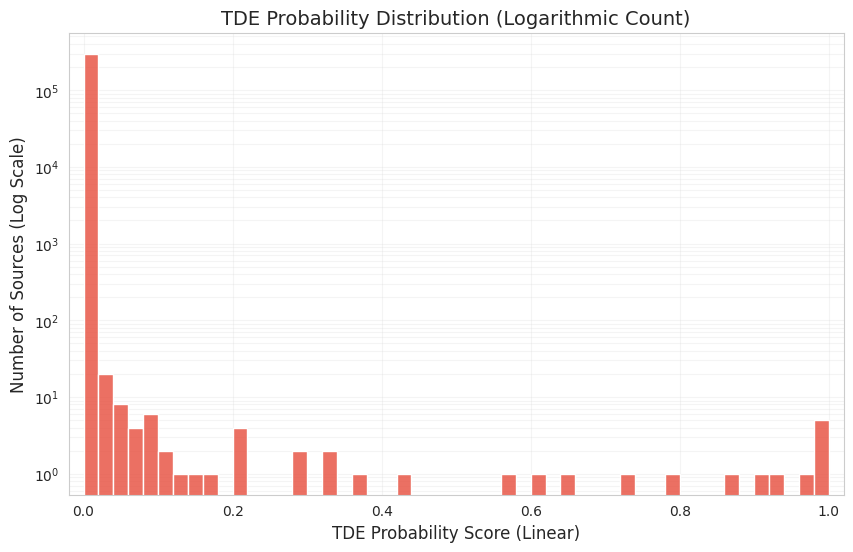

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def analyze_sdss_tde(csv_path):
    # 1. 加载数据
    df = pd.read_csv(csv_path)
    
    # 清洗数据：去除列名和数值中的空格，并转换为数值类型
    df.columns = df.columns.str.strip()
    df['TDE_prob'] = pd.to_numeric(df['TDE_prob'], errors='coerce')
    df['median_snr'] = pd.to_numeric(df['median_snr'], errors='coerce')
    
    # 2. 基础统计
    print("--- TDE 概率统计描述 ---")
    print(df['TDE_prob'].describe())
    
    # 统计高概率候选者数目
    high_prob_threshold = 0.5
    candidates = df[df['TDE_prob'] >= high_prob_threshold]
    print(f"\n 概率 >= {high_prob_threshold} 的候选者数目: {len(candidates)} (总数: {len(df)})")

    # 3. 绘图：分布直方图
    plt.figure(figsize=(14, 6))
    sns.set_style("ticks")

    # --- 左图：线性坐标 ---
    plt.subplot(1, 2, 1)
    sns.histplot(df['TDE_prob'], bins=50, kde=True, color='#2c3e50', alpha=0.7)
    plt.title('TDE Probability Distribution (Linear)')
    plt.xlabel('TDE_prob')
    plt.ylabel('Frequency')

    # --- 右图：对数坐标（修复版） ---
    plt.subplot(1, 2, 2)
    
    # 核心修复：
    # 1. 过滤掉恰好等于 0 的点以避免 log(0) 错误，或者给一个极小的偏移
    # 2. 手动指定 binrange，确保显示 0 到 1 的全范围
    log_df = df['TDE_prob'].copy()
    
    # 如果你想看到 0 处的柱子，给它一个非常小的值（比如 1e-6）
    # 如果只想看有概率的目标，就只选 > 0 的部分
    plot_data = log_df[log_df > 0] 

    if len(plot_data) > 0:
        sns.histplot(
            plot_data, 
            bins=50, 
            color='#e74c3c', 
            log_scale=(False, True), # X轴线性，Y轴对数
            binrange=(0, 1)          # 强制显示 0-1 范围
        )
    else:
        plt.text(0.5, 0.5, "No non-zero probabilities found", ha='center')

    plt.title('TDE Probability Distribution (Log Scale Y)')
    plt.xlabel('TDE_prob')
    plt.ylabel('Count (Log Scale)')
    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.savefig('sdss_tde_distribution.png', dpi=300)

    # 4. 进阶：SNR 与 TDE 概率的相关性分析
    plt.figure(figsize=(8, 6))
    plt.scatter(df['median_snr'], df['TDE_prob'], alpha=0.3, s=10, c=df['TDE_prob'], cmap='viridis')
    plt.axhline(y=0.5, color='r', linestyle='--')
    plt.title('SNR vs TDE Probability')
    plt.xlabel('Median SNR')
    plt.ylabel('TDE_prob')
    plt.colorbar(label='TDE Probability')
    plt.savefig('snr_vs_tde.png', dpi=300)
    
    
def analyze_sdss_tde_v2(csv_path):
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    df = pd.read_csv(csv_path)
    df.columns = df.columns.str.strip()
    df['TDE_prob'] = pd.to_numeric(df['TDE_prob'], errors='coerce').fillna(0)

    plt.figure(figsize=(10, 6))
    sns.set_style("whitegrid")

    # 1. 设置分箱：50个箱子，范围0到1
    bins = np.linspace(0, 1, 51)
    
    # 2. 绘制直方图
    # 注意：我们手动处理对数纵轴，因为 sns.histplot 的 log_scale 在处理 0 值 Count 时有时会报错
    ax = sns.histplot(
        df['TDE_prob'], 
        bins=bins, 
        color='#e74c3c', 
        edgecolor='white',
        alpha=0.8
    )

    # 3. 关键步骤：将纵坐标设为对数
    ax.set_yscale('log')

    # 4. 细节优化
    plt.title('TDE Probability Distribution (Logarithmic Count)', fontsize=14)
    plt.xlabel('TDE Probability Score (Linear)', fontsize=12)
    plt.ylabel('Number of Sources (Log Scale)', fontsize=12)
    
    plt.xlim(-0.02, 1.02) # 稍微宽一点，防止 0 和 1 的柱子被切掉
    
    # 5. 添加中值和分位数辅助线（可选）
    # print(f"Non-zero sources: {(df['TDE_prob'] > 0).sum()}")

    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.savefig('tde_distribution_log_y.png', dpi=300, bbox_inches='tight')
    plt.show()

    

if __name__ == "__main__":
    # 请确保文件名匹配
    #analyze_sdss_tde('merged_output_tes_f1.csv')
    analyze_sdss_tde_v2('merged_output_tes_f1.csv')